# Clustering of cell types based on ATACseq data

## creating ATAC data frame with only our cell types

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
ATAC_seq = pd.read_csv('data/ATAC_pfiltered.csv')

Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

ATAC_seq_gd_anot = pd.concat([ATAC_seq[[
        "ImmGenATAC1219.peakID",
        "chrom",
        "Summit",
        "mm10.60way.phastCons_scores",
        "_-log10_bestPvalue",
        "Included.in.systematic.analysis",
        "TSS", 
        "genes.within.100Kb"
    ]],
    ATAC_seq[Tgd_cells[1:]].copy()], axis=1)

ATAC_seq_gd_anot.to_csv('data/ATAC_seq_gd_anot.csv', index=False, header=True)
ATAC_seq_gd_check = pd.read_csv('data/ATAC_seq_gd_anot.csv')
ATAC_seq_gd_check

## creating lists of each cell group

In [ ]:
print("Tgd_cell_lineage:", Tgd_cells[1:])

gdT = ["Tgd.g2+d17.24a+.Th",
    "Tgd.g2+d17.LN",
    "Tgd.g2+d1.24a+.Th",
    "Tgd.g2+d1.LN",
    "Tgd.g1.1+d1.24a+.Th",
    "Tgd.g1.1+d1.LN",
    "Tgd.Sp"]
print("gdT:", gdT)

abT = ["preT.DN1.Th",
    "preT.DN2a.Th",
    "preT.DN2b.Th",
    "preT.DN3.Th",
    "T.DN4.Th",
    "T.ISP.Th",
    "T.DP.Th",
    "T.4.Th",
    "T.8.Th",
    "T.4.Nve.Sp",
    "T.4.Nve.Fem.Sp",
    "T.8.Nve.Sp",
    "Treg.4.FP3+.Nrplo.Co",
    "Treg.4.25hi.Sp",
    "NKT.Sp"]
print("abT:", abT)

Act_T = ["T.4.Sp.aCD3+CD40.18hr",
         "T8.TN.P14.Sp",
         "T8.IEL.LCMV.d7.SI",
         "T8.TE.LCMV.d7.Sp",
         "T8.MP.LCMV.d7.Sp",
         "T8.Tcm.LCMV.d180.Sp",
         "T8.Tem.LCMV.d180.Sp",
         "NKT.Sp.LPS.3hr",
         "NKT.Sp.LPS.18hr",
         "NKT.Sp.LPS.3d"]
print("Act_T:", Act_T)

B_cells = ["proB.CLP.BM",
           "proB.FrA.BM",
           "proB.FrBC.BM",
           "preB.FrD.BM",
           "B.FrE.BM",
           "B1b.PC",
           "B.T1.Sp",
           "B.T2.Sp",
           "B.T3.Sp",
           "B.Sp",
           "B.Fem.Sp",
           "B.MZ.Sp",
           "B.Fo.Sp",
           "B.mem.Sp",
           "B.GC.CB.Sp",
           "B.GC.CC.Sp",
           "B.PB.Sp",
           "B.PC.Sp",
           "B.PC.BM"]
print("B_cells:", B_cells)

Stem = ["LTHSC.34-.BM",
         "LTHSC.34+.BM",
         "STHSC.150-.BM",
         "MPP4.135+.BM",
         "MPP3.48+.BM"]
print("Stem:", Stem)

ILC_cells = ["NK.27+11b-.BM",
        "NK.27+11b+.BM",
        "NK.27-11b+.BM",
        "NK.27+11b-.Sp",
        "NK.27+11b+.Sp",
        "NK.27-11b+.Sp",
        "ILC2.SI",
        "ILC3.NKp46-CCR6-.SI",
        "ILC3.NKp46+.SI",
        "ILC3.CCR6+.SI"]
print("ILC:", ILC_cells)

MF_GN_cells = ["GN.BM",
                "GN.Sp",
                "GN.Thio.PC",
                "MF.pIC.Alv.Lu",
                "MF.226+II+480lo.PC",
                "MF.ICAM+480hi.PC",
                "MF.RP.Sp",
                "MF.LP.SI",
                "MF.Alv.Lu",
                "MF.microglia.CNS",
                "MF.PC",
                "MF.Fem.PC"]
print("MF/GN:", MF_GN_cells)

Mo = ["Mo.6C+II-.Bl",
       "Mo.6C-II-.Bl"]
print("Mo:", Mo)

DCs = ["DC.4+.Sp",
        "DC.8+.Sp",
        "DC.pDC.Sp",
        "DC.103+11b+.SI",
        "DC.103+11b-.SI"]
print("DCs:", DCs)

Stroma = ["FRC.SLN",
          "IAP.SLN",
          "BEC.SLN",
          "LEC.SLN",
          "Ep.MEChi.Th"]
print("Stroma:", Stroma)

cells_groups = pd.DataFrame({
    "gdT": pd.Series(gdT),
    "abT": pd.Series(abT),
    "Act_T": pd.Series(Act_T),
    "B_cells": pd.Series(B_cells),
    "Stem": pd.Series(Stem),
    "ILC": pd.Series(ILC_cells),
    "MF/GN": pd.Series(MF_GN_cells),
    "Mo": pd.Series(Mo),
    "DC": pd.Series(DCs),
    "Stroma": pd.Series(Stroma)
})
cells_groups.to_csv('data/cells_groups.csv', index=False, header=True)
cells_groups_check = pd.read_csv('data/cells_groups.csv')
cells_groups_check


## clustering using PCA

### doing PCA analyses

First I have to rearrange the data frame, so that rows = cell types

In [ ]:
ATAC_seq_PCA = ATAC_seq.iloc[:,8:].T.copy()
ATAC_seq_PCA.columns = ATAC_seq["ImmGenATAC1219.peakID"]
ATAC_seq_PCA_gd = ATAC_seq[Tgd_cells[1:]].T.copy()
ATAC_seq_PCA_gd.columns = ATAC_seq["ImmGenATAC1219.peakID"]

Now I perform PCA analysis with all cell types and also just with the Tgd lineage

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = ATAC_seq_PCA.select_dtypes(float).values


X_scaled = StandardScaler().fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled)


pca_ATAC = pd.DataFrame(pcs, index=ATAC_seq_PCA.index,
                     columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
print(pca.explained_variance_ratio_)
pca_ATAC_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum())


In [ ]:
X = ATAC_seq_PCA_gd.select_dtypes(float).values


X_scaled_gd = StandardScaler().fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled_gd)


pca_ATAC_gd = pd.DataFrame(pcs, index=ATAC_seq_PCA_gd.index,
                     columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
print(pca.explained_variance_ratio_)
pca_ATAC_gd_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum())


visualizing the PCA results

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cell_group_map = {
    cell: group
    for group in cells_groups.columns
    for cell in cells_groups[group].dropna()
}

pca_ATAC["cell_type"] = pca_ATAC.index.map(cell_group_map).fillna("other")

group_palette = {
    "gdT": "darkorchid",
    "abT": "tab:green",
    "Act_T": "tab:orange",
    "B_cells": "tab:blue",
    "Stem": "tab:red",
    "ILC": "darkslategrey",
    "MF/GN": "tab:brown",
    "Mo": "tab:pink",
    "DC": "tab:cyan",
    "Stroma": "tab:olive",
    "other": "lightgrey",
}

sns.scatterplot(
    data=pca_ATAC,
    x="PC1",
    y="PC2",
    hue="cell_type",
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.xlabel("PC1" + f" ({pca_ATAC_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_ATAC_exp_var[1]:.1%})")
plt.title("PCA of all cell types based on ATAC-seq data (PC1 vs PC2)")
plt.savefig("tilmann_plots/PCA of all cell types based on ATAC-seq data (PC1 vs PC2).png", dpi=300, bbox_inches="tight")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


- some cells types are grouped quite well using PCA analysis
    - especially B-cells are grouped well
    - T-cells (with ILC) are all grouped together, but there is no distance visible between the diffrenet kinds of T-cells
- the first two PCAs only explain 17,7% of variance
    - this is likely due to the large number of original dimensions

In [ ]:
sns.scatterplot(
    data=pca_ATAC,
    x="PC1",
    y="PC3",
    hue="cell_type",
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.xlabel("PC1" + f" ({pca_ATAC_exp_var[0]:.1%})")
plt.ylabel("PC3" + f" ({pca_ATAC_exp_var[2]:.1%})")
plt.title("PCA of all cell types based on ATAC-seq data (PC1 vs PC3)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [ ]:
pca_ATAC_gd["sample"] = pca_ATAC_gd.index

palette = dict(zip(
    pca_ATAC_gd["sample"],
    sns.color_palette("viridis", n_colors=len(pca_ATAC_gd))
))

sns.scatterplot(data=pca_ATAC_gd, x="PC1", y="PC2", hue="sample", palette=palette, s=100, alpha=0.8)
plt.xlabel("PC1" + f" ({pca_ATAC_gd_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_ATAC_gd_exp_var[1]:.1%})")
plt.title("PCA of Tgd lineage based on ATAC-seq data (PC1 vs PC2)")
plt.savefig("tilmann_plots/PCA of Tgd lineage based on ATAC-seq data (PC1 vs PC2).png", dpi=300, bbox_inches="tight")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

It looks like there is clear differentiation route in these two artifical dimensions

In [ ]:
sns.scatterplot(data=pca_ATAC_gd, x="PC1", y="PC3", hue="sample", palette=palette, s=100, alpha=0.8)
plt.xlabel("PC1" + f" ({pca_ATAC_gd_exp_var[0]:.1%})")
plt.ylabel("PC3" + f" ({pca_ATAC_gd_exp_var[2]:.1%})")
plt.title("PCA of Tgd lineage based on ATAC-seq data (PC1 vs PC3)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### clustering using k-means and comparing with cell lineage

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

pca_features = [f"PC{i+1}" for i in range(min(10, pca_ATAC.shape[1]))]
X_pca = pca_ATAC[pca_features].values

silhouette_scores = []
k_values = range(2, 20)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on PCA-transformed ATAC data")
plt.grid(True, alpha=0.3)
plt.show()

kmeans_opt = KMeans(n_clusters=best_k, random_state=42, n_init=20)
pca_ATAC["kmeans_cluster"] = kmeans_opt.fit_predict(X_pca).astype(str)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_ATAC,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab20",
    s=100,
    alpha=0.8
)
plt.title(f"KMeans clustering on PCA of ATAC data (k={best_k})")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.savefig("tilmann_plots/PCA_kmeans_clustering_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

print(pca_ATAC.groupby(["kmeans_cluster", "cell_type"]).size().unstack(fill_value=0))


### clustering only the T cells with PCA and k-means

In [ ]:
cells_groups = pd.read_csv('data/cells_groups.csv')
cells_groups_T = cells_groups.iloc[:, 0:3]
T_cells = cells_groups_T.melt(var_name="group", value_name="cell").dropna()
T_cells

In [ ]:

ATAC_seq = pd.read_csv('data/ATAC_pfiltered.csv')

ATAC_seq_PCA_T = ATAC_seq[T_cells["cell"]].T.copy()
ATAC_seq_PCA_T.columns = ATAC_seq["ImmGenATAC1219.peakID"]

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = ATAC_seq_PCA_T.select_dtypes(float).values


X_scaled = StandardScaler().fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled)


pca_ATAC_T = pd.DataFrame(pcs, index=ATAC_seq_PCA_T.index,
                     columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
print(pca.explained_variance_ratio_)
pca_ATAC_T_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum())

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cell_group_map = {
    cell: group
    for group in cells_groups.columns
    for cell in cells_groups[group].dropna()
}

pca_ATAC_T["cell_type"] = pca_ATAC_T.index.map(cell_group_map).fillna("other")

group_palette = {
    "gdT": "darkorchid",
    "abT": "tab:green",
    "Act_T": "tab:orange",
    "B_cells": "tab:blue",
    "Stem": "tab:red",
    "ILC": "darkslategrey",
    "MF/GN": "tab:brown",
    "Mo": "tab:pink",
    "DC": "tab:cyan",
    "Stroma": "tab:olive",
    "other": "lightgrey",
}

sns.scatterplot(
    data=pca_ATAC_T,
    x="PC1",
    y="PC2",
    hue="cell_type",
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.xlabel("PC1" + f" ({pca_ATAC_T_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_ATAC_T_exp_var[1]:.1%})")
plt.title("PCA of T cells based on ATAC-seq data (PC1 vs PC2)")
plt.savefig("tilmann_plots/PCA of T cells based on ATAC-seq data (PC1 vs PC2).png", dpi=300, bbox_inches="tight")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

pca_features = [f"PC{i+1}" for i in range(min(10, pca_ATAC_T.shape[1]))]
X_pca = pca_ATAC_T[pca_features].values

kmeans_opt = KMeans(n_clusters=3, random_state=42, n_init=20)
pca_ATAC_T["kmeans_cluster"] = kmeans_opt.fit_predict(X_pca).astype(str)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_ATAC_T,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab10",
    s=100,
    alpha=0.8
)
plt.title(f"KMeans clustering on PCA of ATAC data of T cells(k={best_k})")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

print(pca_ATAC_T.groupby(["kmeans_cluster", "cell_type"]).size().unstack(fill_value=0))

T cells are difficult to distinguish based on their chromatin signature using k means

## trying U-map for visualization

In [ ]:
import umap

umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)

X_raw = ATAC_seq_PCA.select_dtypes(float).values
X_raw_scaled = StandardScaler().fit_transform(X_raw)

X_umap = umap_reducer.fit_transform(X_raw_scaled)
umap_df = pd.DataFrame(
    X_umap,
    index=ATAC_seq_PCA.index,
    columns=['UMAP1', 'UMAP2']
)
umap_df['cell_type'] = pca_ATAC['cell_type']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='cell_type',
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.title('UMAP of all cell types based on raw ATAC-seq data')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

kmeans_umap = KMeans(n_clusters=best_k, random_state=42, n_init=20)
umap_df['umap_cluster'] = kmeans_umap.fit_predict(umap_df[['UMAP1', 'UMAP2']]).astype(str)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='umap_cluster',
    palette='tab20',
    s=100,
    alpha=0.8
)
plt.title(f'KMeans clusters on UMAP projection of raw ATAC data (k={best_k})')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()


- some cell groups are more distinct than others
    - this can also be seen with the k-means clustering
- k-means clustering seems to give similar results as the Umap

## Heatmap with hierarchical clustering (replicating figure 2a from Yoshida et al., but only with our cells types)

### load a data frame with only our cell types

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ATAC_seq = pd.read_csv('data/ATAC_pfiltered.csv')
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]
ATAC_seq_gd = ATAC_seq[Tgd_cells[1:]].copy()
ATAC_seq_gd

,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,0.11,0.40,0.77,0.11,0.10,0.35,0.11,0.76,0.53,1.46,0.11,0.12,0.86
1,0.11,0.46,0.11,0.47,0.10,0.58,0.11,0.29,0.53,0.51,0.11,0.70,0.13
2,0.11,0.77,0.84,1.34,1.69,0.34,1.39,1.58,3.16,0.51,0.99,0.12,0.73
3,1.58,0.77,0.77,0.47,1.02,0.10,1.33,0.10,1.48,0.15,0.11,1.26,0.73
4,0.11,0.40,0.84,0.47,0.10,0.58,1.33,1.27,1.11,0.51,2.86,0.70,0.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
362325,3.49,2.09,4.64,4.17,7.10,6.93,9.58,9.65,11.37,3.98,15.78,5.85,19.30
362326,2.15,1.76,2.59,2.55,4.00,10.15,6.88,20.55,8.96,2.34,10.00,9.77,10.93
362327,2.58,3.32,5.06,3.37,4.55,8.41,8.61,19.64,8.96,3.61,13.42,14.05,9.01
362328,3.04,3.56,5.76,8.18,10.40,15.50,12.38,15.54,10.92,3.52,11.73,8.31,12.91


### creating the heatmap based on pearson correlation

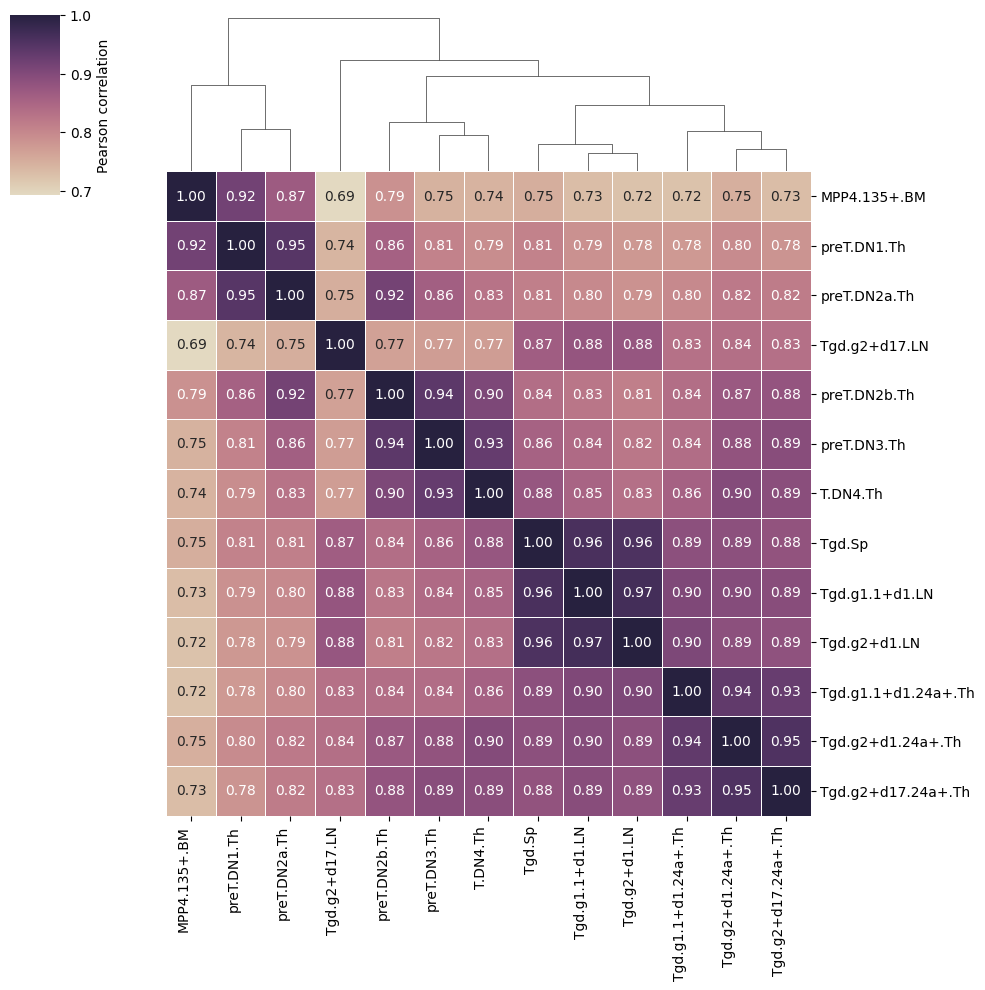

In [ ]:
import seaborn as sns

ATAC_gd_corr_matrix_pear = ATAC_seq_gd.corr(method='pearson')

vmin, vmax = ATAC_gd_corr_matrix_pear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_corr_matrix_pear,
    cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True),
    center= (ATAC_gd_corr_matrix_pear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
plt.savefig("tilmann_plots/Pearson correlation clustermap of ATAC-seq cell types (average linkage).png", dpi=300, bbox_inches="tight")
plt.savefig("plots_for_poster/Pearson correlation clustermap of ATAC-seq cell types (average linkage).png", dpi=300, bbox_inches="tight")
plt.show()


- The IL17 expressing Tgd.g2+d17.LN cell type seems to be clustered apart from the other cell types, which should be closer acording to the lineage.
- This is consistent with to results from the PCA analysis
- otherwise the clustering of cell types is very close to the cell lineage
    - early progenitors differ the most from other cell types in their chromatin profile
    - cell types of similar differentiation levels cluster together, rather than cell types, which are directly related
    - likely that differentiation has similar mechanisms in all cell types and is driven by similar changes in chromatin profiles

### heatmap using spearman correlation

In [ ]:
ATAC_gd_corr_matrix_spear = ATAC_seq_gd.corr(method='spearman')

vmin, vmax = ATAC_gd_corr_matrix_spear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_corr_matrix_spear,
    cmap='viridis',
    center= (ATAC_gd_corr_matrix_spear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Spearman correlation clustermap of ATAC-seq cell types (average linkage)', y=1)
plt.show()

### trying out different similarity metrics

single linkage

In [ ]:
ATAC_gd_corr_matrix_pear = ATAC_seq_gd.corr(method='pearson')

vmin, vmax = ATAC_gd_corr_matrix_pear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_corr_matrix_pear,
    cmap='viridis',
    center= (ATAC_gd_corr_matrix_pear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='single',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of ATAC-seq cell types (single linkage)', y=1)
plt.show()



ATAC_gd_corr_matrix_spear = ATAC_seq_gd.corr(method='spearman')

vmin, vmax = ATAC_gd_corr_matrix_spear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_corr_matrix_spear,
    cmap='viridis',
    center= (ATAC_gd_corr_matrix_spear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='single',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Spearman correlation clustermap of ATAC-seq cell types (single linkage)', y=1)
plt.show()

complete linkage

In [ ]:
ATAC_gd_corr_matrix_pear = ATAC_seq_gd.corr(method='pearson')

vmin, vmax = ATAC_gd_corr_matrix_pear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_corr_matrix_pear,
    cmap='viridis',
    center= (ATAC_gd_corr_matrix_pear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='complete',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of ATAC-seq cell types (complete linkage)', y=1)
plt.show()



ATAC_gd_corr_matrix_spear = ATAC_seq_gd.corr(method='spearman')

vmin, vmax = ATAC_gd_corr_matrix_spear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_corr_matrix_spear,
    cmap='viridis',
    center= (ATAC_gd_corr_matrix_spear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='complete',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Spearman correlation clustermap of ATAC-seq cell types (complete linkage)', y=1)
plt.show()

- I would choose the clustering with pearson correlation and avarage linkage
    - it shows clustering resembling the cell lineage
    - it uses more information than single and complete linkage
    - it captures the distance IL17 producing Tgd cells have to other cell types better than complete linkage
    - pearson correlation shows the clusters more clearly than spearman with all linkage methods

### seperating TSS OCRs from DE OCRs like in Yoshida et al.

In [ ]:
ATAC_seq_TSSOCRs = ATAC_seq[ATAC_seq["TSS"].notna()].copy()
ATAC_seq_gd_TSSOCRs = ATAC_seq_TSSOCRs[Tgd_cells[1:]].copy()
ATAC_seq_DEOCRs = ATAC_seq[ATAC_seq["TSS"].isna()].copy()
ATAC_seq_gd_DEOCRs = ATAC_seq_DEOCRs[Tgd_cells[1:]].copy()

#### Spearman

In [ ]:
ATAC_gd_DEOCRs_corr_matrix_spear = ATAC_seq_gd_DEOCRs.corr(method='spearman')

vmin, vmax = ATAC_gd_DEOCRs_corr_matrix_spear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_DEOCRs_corr_matrix_spear,
    cmap='viridis',
    center= (ATAC_gd_DEOCRs_corr_matrix_spear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Spearman correlation clustermap of DEOCRs ATAC-seq cell types', y=1)
plt.show()

ATAC_gd_TSSOCRs_corr_matrix_spear = ATAC_seq_gd_TSSOCRs.corr(method='spearman')

vmin, vmax = ATAC_gd_DEOCRs_corr_matrix_spear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_TSSOCRs_corr_matrix_spear,
    cmap='viridis',
    center= (ATAC_gd_DEOCRs_corr_matrix_spear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Spearman correlation clustermap of TSSOCRs ATAC-seq cell types', y=1)
plt.show()


- the colormap for both heatmaps is adjusted for the maximum range of both combined (equal to the maximum range of correlation based on DE-OCRs)

#### Pearson

In [ ]:
ATAC_gd_DEOCRs_corr_matrix_pearson = ATAC_seq_gd_DEOCRs.corr(method='pearson')

vmin, vmax = ATAC_gd_DEOCRs_corr_matrix_pearson.min().min(), 1

g = sns.clustermap(
    ATAC_gd_DEOCRs_corr_matrix_pearson,
    cmap='viridis',
    center= (ATAC_gd_DEOCRs_corr_matrix_pearson.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of DEOCRs ATAC-seq cell types', y=1)
plt.savefig("tilmann_plots/Pearson correlation clustermap of DEOCRs ATAC-seq cell types (average linkage).png", dpi=300, bbox_inches="tight")
plt.show()

ATAC_gd_TSSOCRs_corr_matrix_pearson = ATAC_seq_gd_TSSOCRs.corr(method='pearson')

vmin, vmax = ATAC_gd_DEOCRs_corr_matrix_pearson.min().min(), 1

g = sns.clustermap(
    ATAC_gd_TSSOCRs_corr_matrix_pearson,
    cmap='viridis',
    center= (ATAC_gd_DEOCRs_corr_matrix_pearson.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of TSSOCRs ATAC-seq cell types', y=1)
plt.savefig("tilmann_plots/Pearson correlation clustermap of TSSOCRs ATAC-seq cell types (average linkage).png", dpi=300, bbox_inches="tight")
plt.show()

- both spearman and pearson correlation show less variability with the TSS-OCRs

### correcting for the different sizes of the datasets

In [ ]:
# function for corretion created with Claude Sonnet 4.6

from scipy.stats import pearsonr

def weighted_pearson_matrix(df):
    cols = df.columns
    n_cols = len(cols)
    rho_matrix = np.ones((n_cols, n_cols))
    
    for i, col_i in enumerate(cols):
        for j, col_j in enumerate(cols):
            if i >= j:
                continue
            valid = df[[col_i, col_j]].dropna()
            n = len(valid)
            
            if n < 4:
                rho_matrix[i, j] = np.nan
                rho_matrix[j, i] = np.nan
                continue
            
            r, _ = pearsonr(valid[col_i], valid[col_j])
            rho_matrix[i, j] = r
            rho_matrix[j, i] = r
    
    return pd.DataFrame(rho_matrix, index=cols, columns=cols)

In [ ]:
ATAC_gd_DEOCRs_corr_matrix_pearson_weighted = weighted_pearson_matrix(ATAC_seq_gd_DEOCRs)

vmin, vmax = ATAC_gd_DEOCRs_corr_matrix_pearson_weighted.min().min(), 1

g = sns.clustermap(
    ATAC_gd_DEOCRs_corr_matrix_pearson_weighted,
    cmap='viridis',
    center= (ATAC_gd_DEOCRs_corr_matrix_pearson_weighted.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of DEOCRs ATAC-seq cell types (weighted)', y=1)
plt.show()

ATAC_gd_TSSOCRs_corr_matrix_pearson_weighted = weighted_pearson_matrix(ATAC_seq_gd_TSSOCRs)

vmin, vmax = ATAC_gd_DEOCRs_corr_matrix_pearson_weighted.min().min(), 1

g = sns.clustermap(
    ATAC_gd_TSSOCRs_corr_matrix_pearson_weighted,
    cmap='viridis',
    center= (ATAC_gd_DEOCRs_corr_matrix_pearson_weighted.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of TSSOCRs ATAC-seq cell types (weighted)', y=1)
plt.show()

weighting the correlation acording to the size of the dataset makes no difference to the outcome

# Clustering based on RNAseq data and comparison with ATACseq based clustering

## creating RNAseq data frame with only our cell types

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
RNA_seq = pd.read_csv('data/mmc2.csv')

Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

RNA_seq_gd_anot = RNA_seq[Tgd_cells].copy()
RNA_seq_gd_anot.to_csv('data/RNA_seq_gd_anot.csv', index=False, header=True)
RNA_seq_gd_check = pd.read_csv('data/RNA_seq_gd_anot.csv')
RNA_seq_gd_check

,Unnamed: 0,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,0610005C13Rik,1.021812,1.022363,1.389747,1.024819,1.024482,1.026430,1.023995,1.167561,1.024819,1.023995,1.025543,1.024819,1.023995
1,0610007P14Rik,204.298358,162.641117,206.945221,209.187788,198.421365,215.056475,150.742022,174.031477,115.930664,136.200789,108.850425,102.701399,137.925015
2,0610009B22Rik,76.418169,68.070719,82.468806,89.769337,57.661619,76.399214,47.775227,44.980534,53.461136,42.439750,28.755395,21.517647,29.122837
3,0610009L18Rik,16.947354,15.450717,13.573968,14.427620,8.249482,1.683173,8.554990,8.781962,29.156630,8.937625,10.815319,10.202163,9.033355
4,0610009O20Rik,186.261464,160.246297,125.475307,155.928005,120.692893,118.433597,94.062684,113.600798,102.445617,79.315094,84.643541,106.186930,86.383381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17530,Zyx,1420.833446,1102.093601,727.291384,399.395780,248.382338,142.239852,1307.897371,686.551382,516.204555,1784.703406,1513.145053,1713.069187,1163.327571
17531,Zzef1,120.178140,145.971474,154.743640,132.590213,150.298107,132.912133,233.402516,197.191620,297.953300,309.370289,375.410042,342.058751,322.625713
17532,Zzz3,298.099129,305.759992,260.956800,249.726900,291.366650,274.503519,239.937387,242.350770,295.934847,267.547234,317.709126,350.363612,223.088909
17533,a,1.021812,1.022363,1.024462,1.374003,2.043970,1.497412,1.023995,1.022363,1.024819,1.023995,1.025543,1.024819,1.023995


## clustering with hierarchical clustering and a heatmap like with the ATACseq data

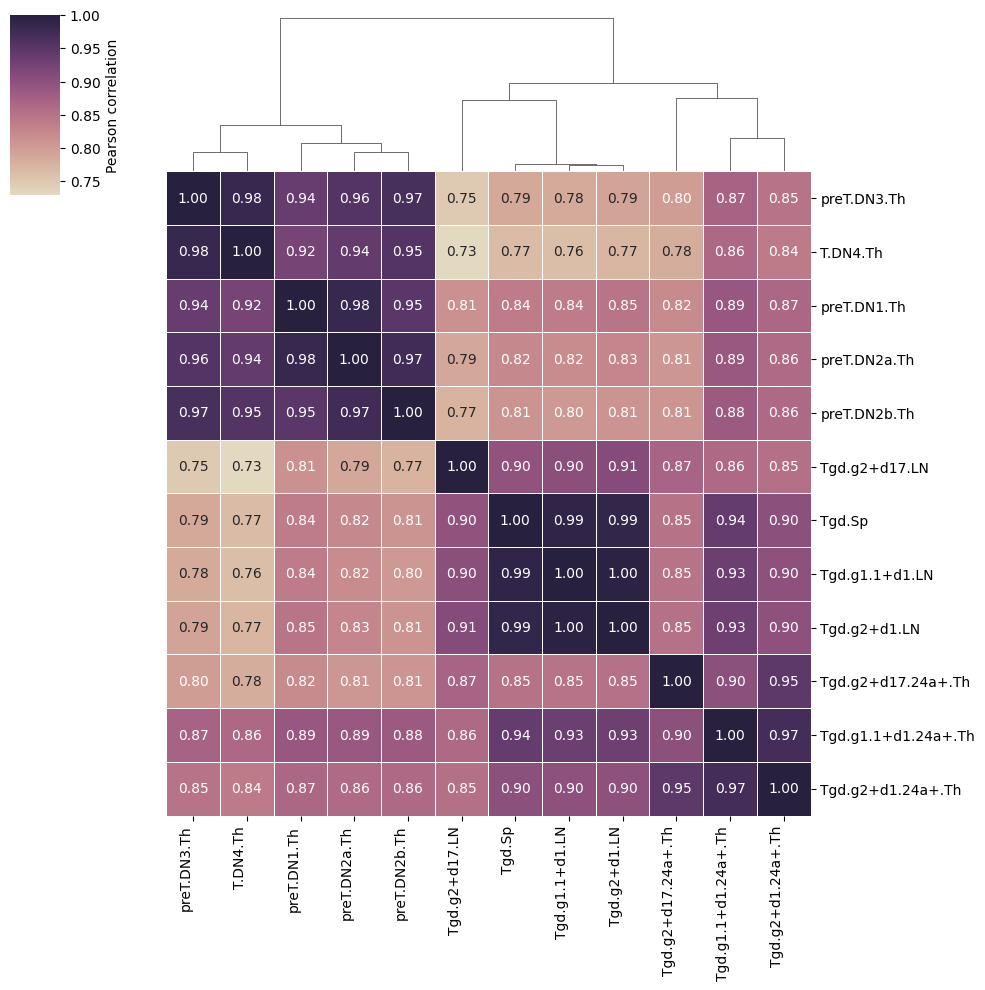

In [ ]:
RNA_seq_gd = RNA_seq[Tgd_cells[1:]].copy()

RNA_gd_corr_matrix_pear = RNA_seq_gd[1:].corr(method='pearson')

vmin, vmax = RNA_gd_corr_matrix_pear.min().min(), 1

g = sns.clustermap(
    RNA_gd_corr_matrix_pear,
    cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True),
    center= (RNA_gd_corr_matrix_pear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
plt.savefig('tilmann_plots/Pearson correlation clustering of RNA-seq cell types (average linkage).png', dpi=300, bbox_inches='tight')
plt.savefig('plots_for_poster/Pearson correlation clustering of RNA-seq cell types (average linkage).png', dpi=300, bbox_inches='tight')
plt.show()

- there is a very clear distinction between Tab progenitor cells and Tgd cells
- it clusters similiarly terminal differentiated cells apart from not fully differentiated
- IL17 producing cells are still quite different from others, but not as far apart as with ATAC data
- some cell types are very similar in their gene expression profile (all progenitor cell before expression of gdTCR and the terminal differentiated Tgd cells except IL17 producers)
- the differences between groups are more pronounced than with clustering based on ATAC data
    - chromation profiles seem to change more gradually during cell differentiation
    - there are clear cutoff points in the gene expression profile
        - very pronounced difference between cell types, that express the gamma delta TCR and those that do not
        - there is also quite a big differnce between fullly differentiated cells and those still developing in the thymus

## PCA, k-means clustering and Umap

### PCA

In [ ]:
RNA_seq_PCA = RNA_seq.iloc[:,8:].T.copy()
RNA_seq_PCA.columns = RNA_seq["Unnamed: 0"]
RNA_seq_PCA_gd = RNA_seq[Tgd_cells[1:]].T.copy()
RNA_seq_PCA_gd.columns = RNA_seq["Unnamed: 0"]

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = RNA_seq_PCA.select_dtypes(float).values


X_scaled = StandardScaler().fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled)


pca_RNA = pd.DataFrame(pcs, index=RNA_seq_PCA.index,
                     columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
print(pca.explained_variance_ratio_)
pca_RNA_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum())

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = RNA_seq_PCA_gd.select_dtypes(float).values


X_scaled = StandardScaler().fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled)


pca_RNA_gd = pd.DataFrame(pcs, index=RNA_seq_PCA_gd.index,
                     columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
print(pca.explained_variance_ratio_)
pca_RNA_gd_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum())

In [ ]:
cells_groups = pd.read_csv('data/cells_groups.csv')

cell_group_map = {
    cell: group
    for group in cells_groups.columns
    for cell in cells_groups[group].dropna()
}

pca_RNA["cell_type"] = pca_RNA.index.map(cell_group_map).fillna("Act_T")

group_palette = {
    "gdT": "darkorchid",
    "abT": "tab:green",
    "Act_T": "tab:orange",
    "B_cells": "tab:blue",
    "Stem": "tab:red",
    "ILC": "darkslategrey",
    "MF/GN": "tab:brown",
    "Mo": "tab:pink",
    "DC": "tab:cyan",
    "Stroma": "tab:olive",
    "other": "lightgrey",
}

sns.scatterplot(
    data=pca_RNA,
    x="PC1",
    y="PC2",
    hue="cell_type",
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.xlabel("PC1" + f" ({pca_RNA_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_RNA_exp_var[1]:.1%})")
plt.title("PCA of all cell types based on RNA-seq data (PC1 vs PC2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.savefig('tilmann_plots/PCA of all cell types based on RNA-seq data (PC1 vs PC2).png', dpi=300, bbox_inches='tight')
plt.show()

sns.scatterplot(
    data=pca_RNA,
    x="PC1",
    y="PC3",
    hue="cell_type",
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.xlabel("PC1" + f" ({pca_RNA_exp_var[0]:.1%})")
plt.ylabel("PC3" + f" ({pca_RNA_exp_var[2]:.1%})")
plt.title("PCA of all cell types based on RNA-seq data (PC1 vs PC3)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

- distinctions between cell groups are less clear than with ATACseq data

In [ ]:
pca_RNA_gd["sample"] = pca_RNA_gd.index

palette = dict(zip(
    pca_RNA_gd["sample"],
    sns.color_palette("viridis", n_colors=len(pca_RNA_gd))
))

sns.scatterplot(data=pca_RNA_gd, x="PC1", y="PC2", hue="sample", palette=palette, s=100, alpha=0.8)
plt.xlabel("PC1" + f" ({pca_RNA_gd_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_RNA_gd_exp_var[1]:.1%})")
plt.title("PCA of Tgd lineage based on RNA-seq data (PC1 vs PC2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('tilmann_plots/PCA of Tgd lineage based on RNA-seq data (PC1 vs PC2).png', dpi=300, bbox_inches='tight')
plt.show()

sns.scatterplot(data=pca_RNA_gd, x="PC1", y="PC3", hue="sample", palette=palette, s=100, alpha=0.8)
plt.xlabel("PC1" + f" ({pca_RNA_gd_exp_var[0]:.1%})")
plt.ylabel("PC3" + f" ({pca_RNA_gd_exp_var[2]:.1%})")
plt.title("PCA of Tgd lineage based on RNA-seq data (PC1 vs PC3)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

- Tgd cells are further apart from the Tab progenitors
    - this overlaps with the hierarchical clustering

### k-means based on PCA

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pca_features = [f"PC{i+1}" for i in range(min(10, pca_RNA.shape[1]))]
X_pca = pca_RNA[pca_features].values

silhouette_scores = []
k_values = range(2, 20)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on PCA-transformed RNA data")
plt.grid(True, alpha=0.3)
plt.show()

kmeans_opt = KMeans(n_clusters=best_k, random_state=42, n_init=20)
pca_RNA["kmeans_cluster"] = kmeans_opt.fit_predict(X_pca).astype(str)

sns.scatterplot(
    data=pca_RNA,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab20",
    s=100,
    alpha=0.8
)
plt.title(f"KMeans clustering on PCA of RNA data (k={best_k})")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

pca_RNA.groupby(["kmeans_cluster", "cell_type"]).size().unstack(fill_value=0)

### Umap

In [ ]:
import umap

umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)

X_raw = pca_RNA.select_dtypes(float).values
X_raw_scaled = StandardScaler().fit_transform(X_raw)

X_umap = umap_reducer.fit_transform(X_raw_scaled)
umap_df = pd.DataFrame(
    X_umap,
    index=pca_RNA.index,
    columns=['UMAP1', 'UMAP2']
)
umap_df['cell_type'] = pca_RNA['cell_type']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='cell_type',
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.title('UMAP of all cell types based on raw RNA-seq data')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

kmeans_umap = KMeans(n_clusters=best_k, random_state=42, n_init=20)
umap_df['umap_cluster'] = kmeans_umap.fit_predict(umap_df[['UMAP1', 'UMAP2']]).astype(str)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='umap_cluster',
    palette='tab20',
    s=100,
    alpha=0.8
)
plt.title(f'KMeans clusters on UMAP projection of raw RNA data (k={best_k})')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

- the clustering seperation of different cell groups with PCA and Umap based on RNAseq data is worse than with ATACseq data